**ASSIGNMENT 7 - Bagging, Boosting, and Stacked Ensemble Models**

NAME : MADUSSREE RAVI

CSE B

DATE : 16-02-2026

3122235001074

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

**LOADING THE DATASET**

In [4]:
# Column names based on wdbc.names
columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbc.data', header=None, names=columns)

# Drop ID column as it is not a feature
df.drop('ID', axis=1, inplace=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 31)


,Diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**EXPLORATORY DATA ANALYSIS (EDA)**

Visualizing class distribution and feature correlations.

C:\Users\Madussree Ravi\AppData\Local\Temp\ipykernel_25404\1571208769.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='viridis')


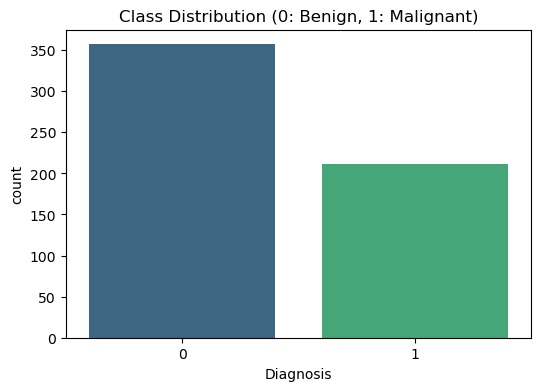

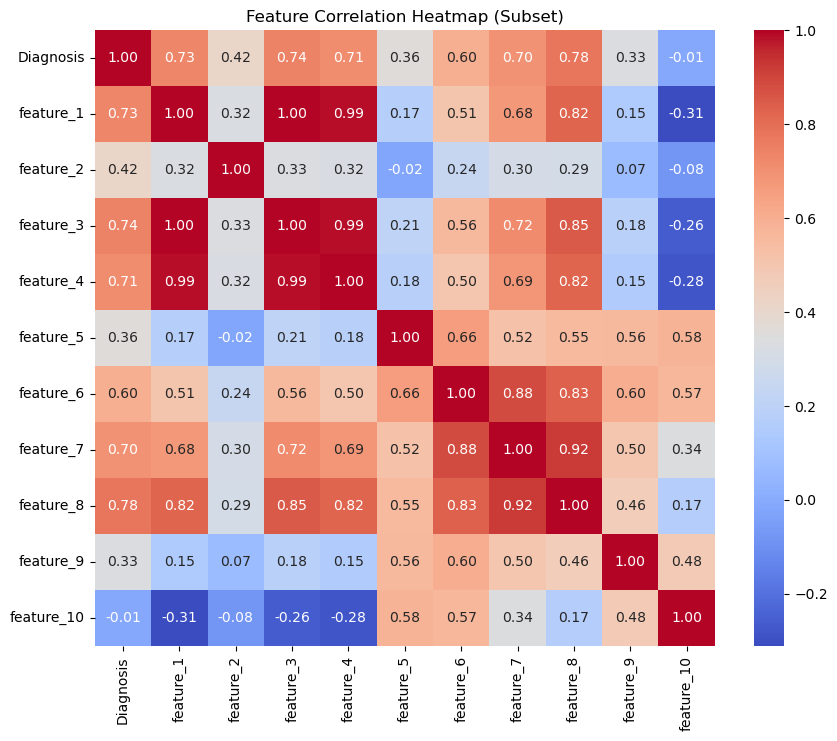

In [10]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df, palette='viridis')
plt.title('Class Distribution (0: Benign, 1: Malignant)')
plt.show()

# Feature Correlation Heatmap (First 10 features for clarity)
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :11].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap (Subset)')
plt.show()

**PREPROCESSING**

Encoding the target labels: M (Malignant) to 1 and B (Benign) to 0.

In [5]:
lb = LabelEncoder()
df['Diagnosis'] = lb.fit_transform(df['Diagnosis'])

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


**MODEL 1: DECISION TREE CLASSIFIER**

Implementing a Decision Tree and evaluating using 5-Fold Cross-Validation.

In [6]:
# Hyperparameter Tuning for Decision Tree
dt_results = []
params = [
    {'criterion': 'gini', 'max_depth': 3},
    {'criterion': 'entropy', 'max_depth': 5},
    {'criterion': 'gini', 'max_depth': None}
]

for p in params:
    clf = DecisionTreeClassifier(criterion=p['criterion'], max_depth=p['max_depth'], random_state=42)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    dt_results.append({
        'Criterion': p['criterion'],
        'Max Depth': p['max_depth'],
        'Avg CV Accuracy': np.mean(cv_scores)
    })

pd.DataFrame(dt_results)

,Criterion,Max Depth,Avg CV Accuracy
0,gini,3.0,0.929670
1,entropy,5.0,0.938462
2,gini,NaN,0.916484


**MODEL 2: RANDOM FOREST CLASSIFIER**

Implementing Random Forest and comparing it with the Decision Tree.

In [7]:
rf_results = []
rf_params = [
    {'n_estimators': 50, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': None}
]

for p in rf_params:
    rf = RandomForestClassifier(n_estimators=p['n_estimators'], max_depth=p['max_depth'], random_state=42)
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
    rf_results.append({
        'n_estimators': p['n_estimators'],
        'Max Depth': p['max_depth'],
        'Avg CV Accuracy': np.mean(cv_scores)
    })

pd.DataFrame(rf_results)

,n_estimators,Max Depth,Avg CV Accuracy
0,50,5.0,0.953846
1,100,10.0,0.956044
2,200,NaN,0.962637


**FINAL MODEL EVALUATION (Tuned Random Forest)**

Using the best configuration to evaluate on the test set.

Accuracy on Test Set: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



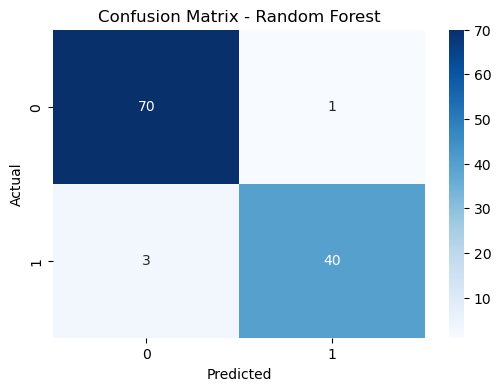

In [8]:
best_rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC CURVE**

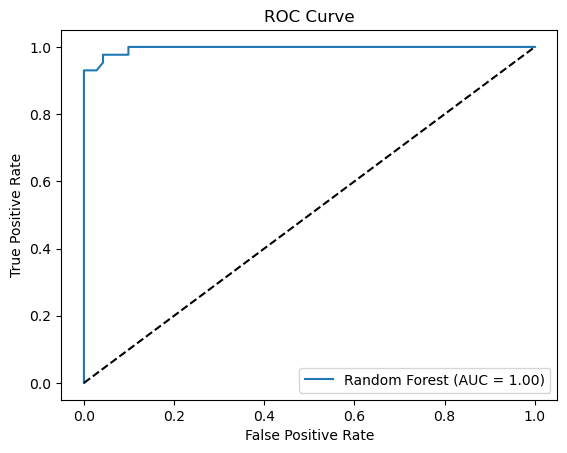

In [9]:
y_prob = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

**LEARNING OUTCOMES**

* Implemented Decision Tree and Random Forest classifiers
* Performed hyperparameter tuning using 5-Fold Cross-Validation
* Compared single-tree models with ensemble learning methods
* Evaluated performance using ROC curves and Confusion Matrices
* **Overfitting:** The Decision Tree with `max_depth: None` showed high variance. Limiting depth improved generalization.
* **Ensemble Benefit:** Random Forest consistently outperformed the Decision Tree by averaging multiple trees, reducing the impact of outliers.
* **Impact of Hyperparameters:** `n_estimators` in Random Forest and `max_depth` in both models were the most influential parameters.